# Eksperimen Komparasi Detektor Bounding Box
Kita akan menguji 4 teknik:
1. **PaddleOCR (Straight Crop - Baseline)**
2. **PaddleOCR (Perspective Crop)**
3. **CRAFT Text Detector**
4. **YOLOv8 OBB (Zero-shot)**

In [1]:
# Install dependencies jika belum ada. Hapus tanda pagar (#) di bawah ini jika ingin menginstall:
# !pip install paddleocr paddlepaddle craft-text-detector ultralytics opencv-python matplotlib

import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- KONFIGURASI PATH DATASET ---
# Tentukan folder dataset gambar yang akan diuji
dataset_dir = "sample dataset (if4901)"

# Format file gambar yang dicari
image_patterns = ["*.jpg", "*.png", "*.jpeg", "*.JPG", "*.PNG", "*.JPEG"]

# Mengumpulkan semua path gambar di dalam direktori dataset
image_files = []
for pattern in image_patterns:
    image_files.extend(glob.glob(f"{dataset_dir}/{pattern}"))

# Menghapus duplikasi path (jika ada) dan mengurutkan nama filenya
image_files = sorted(list(set(image_files)))[:5] # Mengambil 5 gambar pertama untuk pengujian

print(f"Menggunakan {len(image_files)} gambar untuk tes.")


Menggunakan 5 gambar untuk tes.


In [2]:
def plot_full_img_with_boxes(img, boxes, title, is_straight=False, margin=3):
    """
    Fungsi untuk menampilkan gambar halaman penuh beserta bounding box hasil deteksi.
    
    Parameter:
    - img: Gambar asli dalam format OpenCV BGR.
    - boxes: List koordinat bounding box hasil deteksi model.
    - title: Judul plot/gambar yang akan ditampilkan.
    - is_straight: Jika True, gambar kotak persegi biasa (axis-aligned). Jika False, gambar poligon/rotated box.
    - margin: Margin piksel tambahan di sekitar kotak (hanya berlaku jika is_straight=True).
    """
    img_draw = img.copy()
    for box in boxes:
        if is_straight:
            # Menggambar bounding box tegak (bounding rectangle standar)
            box_np = np.array(box, dtype=np.int32)
            x, y, w, h = cv2.boundingRect(box_np)
            y_start = max(0, y - margin)
            y_end = min(img.shape[0], y + h + margin)
            x_start = max(0, x - margin)
            x_end = min(img.shape[1], x + w + margin)
            # Gambar persegi panjang biru
            cv2.rectangle(img_draw, (x_start, y_start), (x_end, y_end), (255, 0, 0), 2)
        else:
            # Menggambar bounding box miring (poligon/rotated box)
            # Pastikan format titik int32 untuk fungsi cv2.polylines
            if len(box) == 4 and isinstance(box[0], (list, tuple, np.ndarray)) and len(box[0]) == 2:
                box_np = np.array(box, dtype=np.int32)
            elif len(box) >= 4: # Format output CRAFT poligon
                box_np = np.array(box, dtype=np.int32)
            else:
                continue
            # Gambar poligon hijau miring
            cv2.polylines(img_draw, [box_np], isClosed=True, color=(0, 255, 0), thickness=2)
    
    # Visualisasi menggunakan matplotlib
    plt.figure(figsize=(6, 8))
    plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
    plt.title(f"Full Page: {title}")
    plt.axis('off')
    plt.show()

def plot_crops(img_name, technique_name, crops):
    """
    Fungsi untuk menampilkan semua potongan gambar (crop) per baris teks dalam bentuk grid.
    Maksimal menampilkan 5 gambar per baris, dan otomatis berpindah ke baris baru.
    
    Parameter:
    - img_name: Nama gambar asli (untuk judul plot).
    - technique_name: Nama teknik deteksi yang digunakan (untuk judul plot).
    - crops: List berisi potongan gambar (crop) hasil deteksi.
    """
    if not crops:
        print(f"[{technique_name}] Tidak ada deteksi untuk {img_name}")
        return
    
    # Menghitung layout grid (maksimal 5 kolom per baris)
    cols = 5
    n = len(crops)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    fig.suptitle(f"{img_name} - {technique_name} (All Crops)", fontsize=14)
    
    # Memastikan axes berbentuk array 2D/1D agar aman saat diakses dengan indeks
    if n == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.array([axes])
    elif cols == 1:
        axes = np.array([[ax] for ax in axes])
    
    # Plot masing-masing crop ke dalam grid
    for i in range(rows * cols):
        r, c = i // cols, i % cols
        ax = axes[r, c]
        if i < n:
            # Ubah format warna OpenCV BGR ke Matplotlib RGB sebelum diplot
            crop_rgb = cv2.cvtColor(crops[i], cv2.COLOR_BGR2RGB)
            ax.imshow(crop_rgb)
            ax.set_title(f"Line {i+1}")
        ax.axis('off') # Sembunyikan axis untuk kotak kosong di sisa grid
        
    plt.tight_layout()
    plt.show()

def get_perspective_crop(img, pts):
    """
    Melakukan crop dengan teknik Perspective Transform dari poligon 4 titik miring 
    menjadi gambar persegi panjang tegak lurus (de-warping).
    
    Parameter:
    - img: Gambar asli OpenCV BGR.
    - pts: Koordinat 4 titik pojok dari bounding box (top-left, top-right, bottom-right, bottom-left).
    
    Return:
    - warped: Gambar hasil crop yang sudah ditegakkan.
    """
    # 1. Mengurutkan koordinat 4 titik: [top-left, top-right, bottom-right, bottom-left]
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)] # Titik top-left punya jumlah x+y terkecil
    rect[2] = pts[np.argmax(s)] # Titik bottom-right punya jumlah x+y terbesar
    
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)] # Titik top-right punya selisih y-x terkecil
    rect[3] = pts[np.argmax(diff)] # Titik bottom-left punya selisih y-x terbesar
    
    (tl, tr, br, bl) = rect
    
    # 2. Menghitung lebar gambar hasil crop baru (maksimum jarak horizontal atas & bawah)
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))
    
    # 3. Menghitung tinggi gambar hasil crop baru (maksimum jarak vertikal kanan & kiri)
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))
    
    # 4. Menentukan koordinat tujuan untuk proyeksi tegak lurus
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")
    
    # 5. Menghitung matriks transformasi perspektif dan melakukan warping
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))
    return warped


### 1. PaddleOCR (Straight Crop - Baseline)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ASUS\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ASUS\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ASUS\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCR

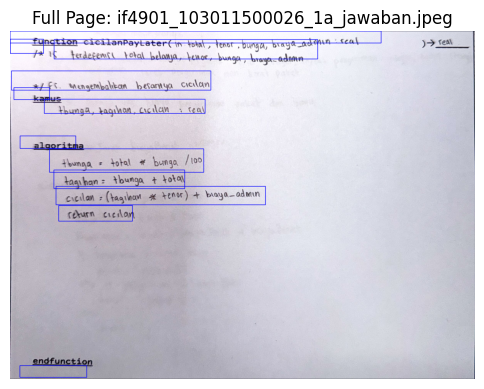

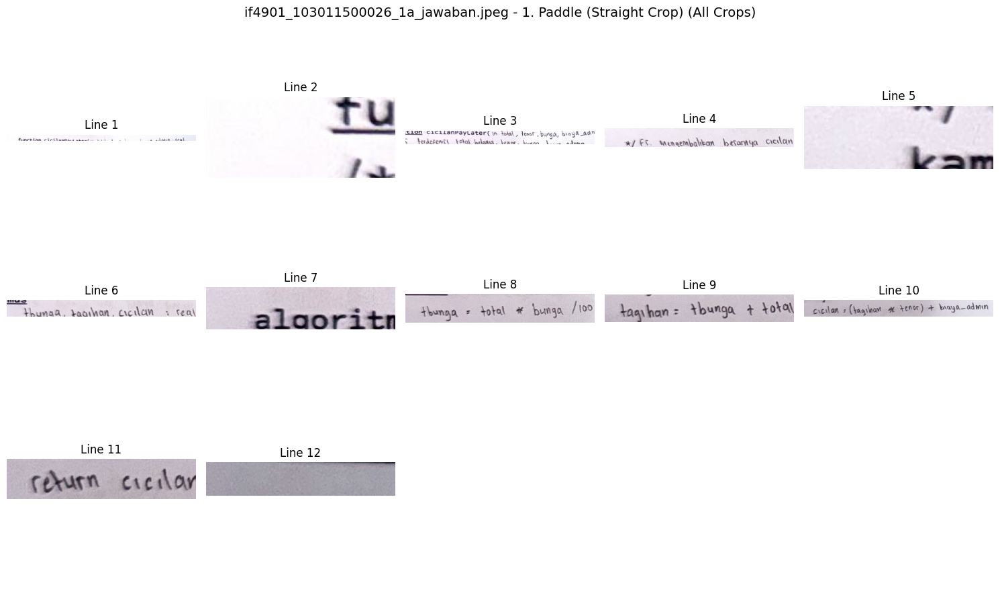

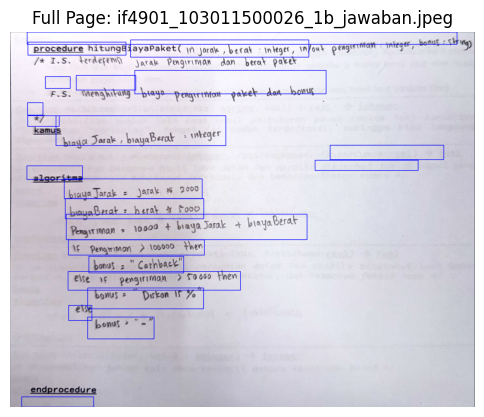

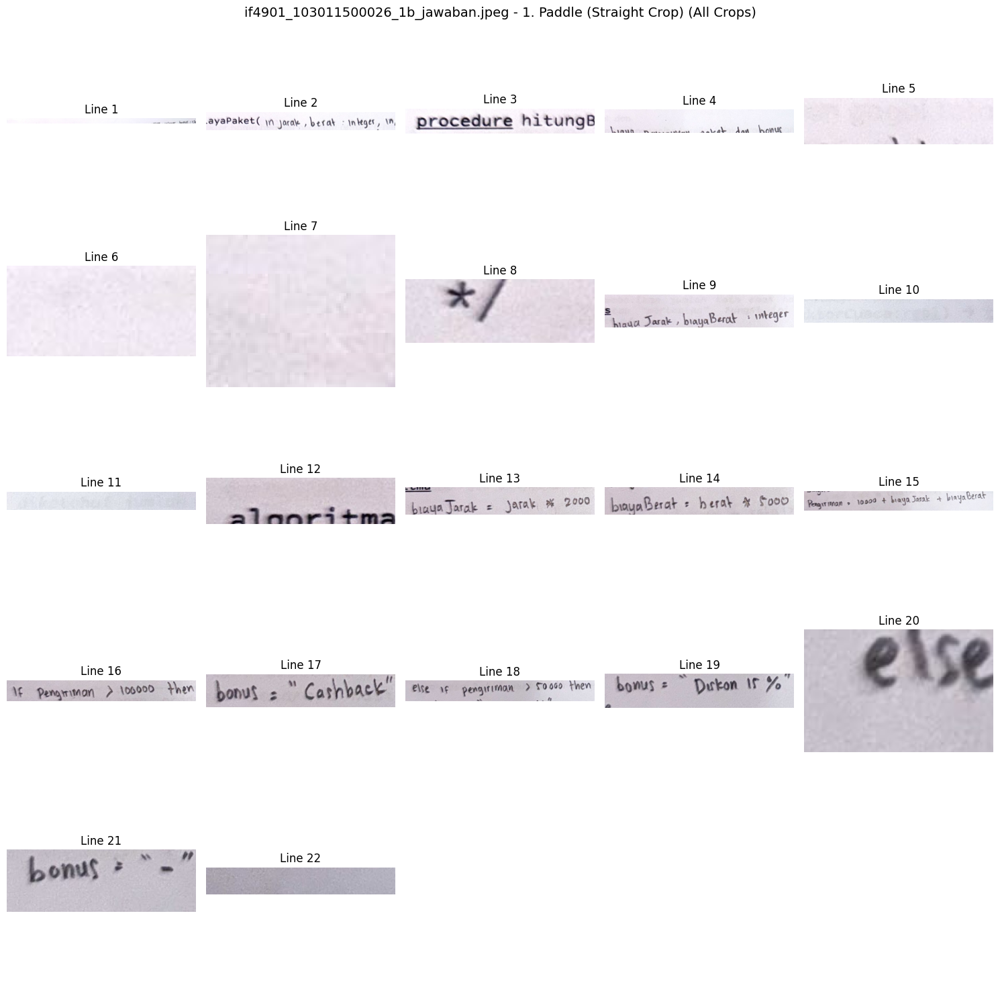

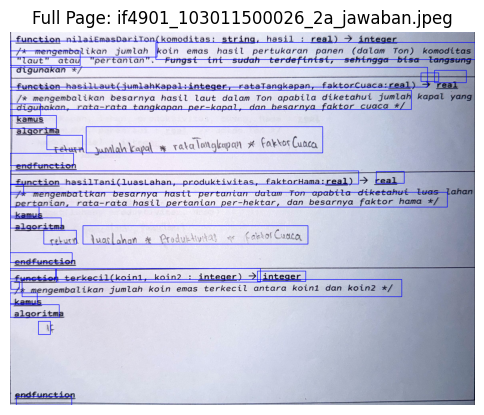

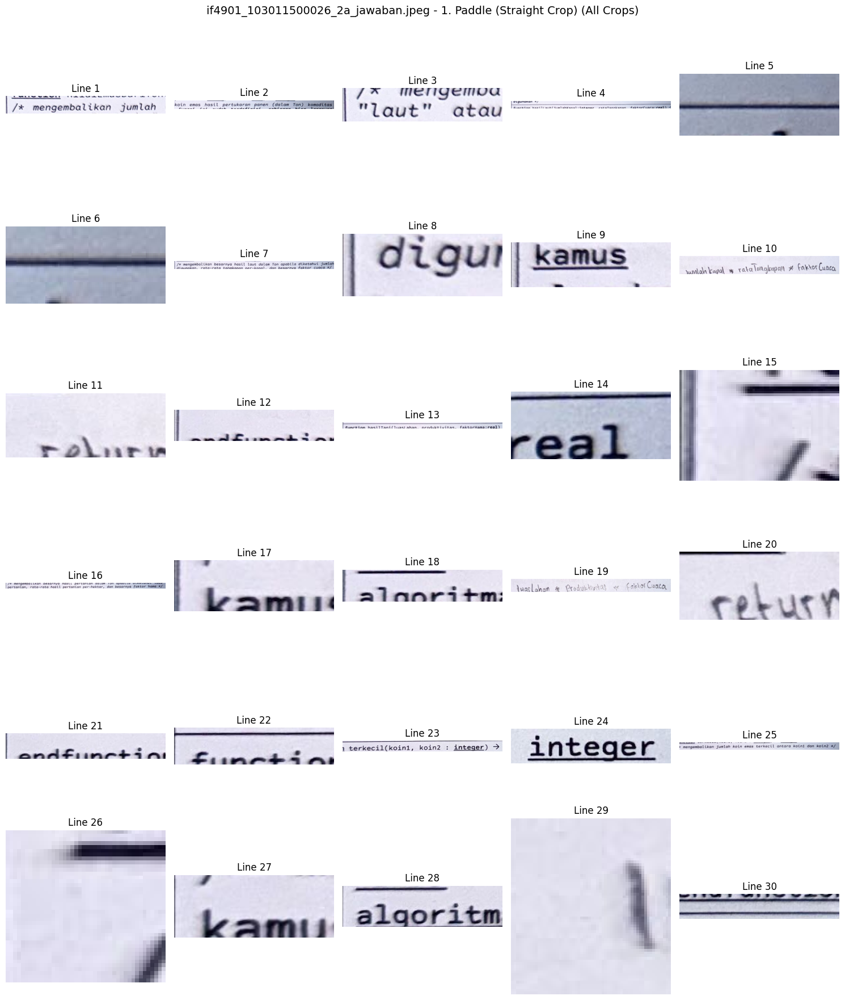

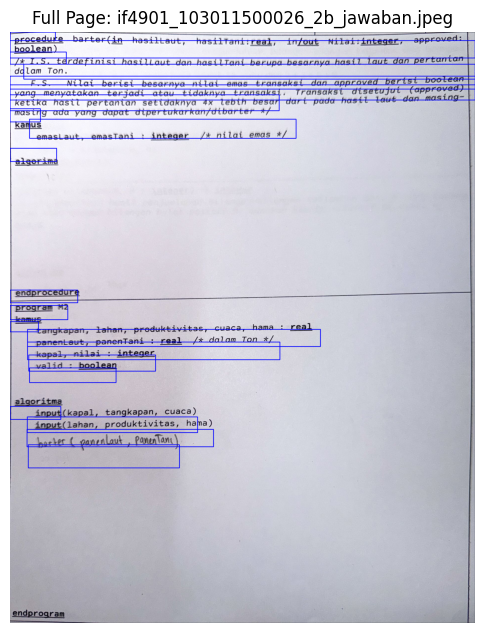

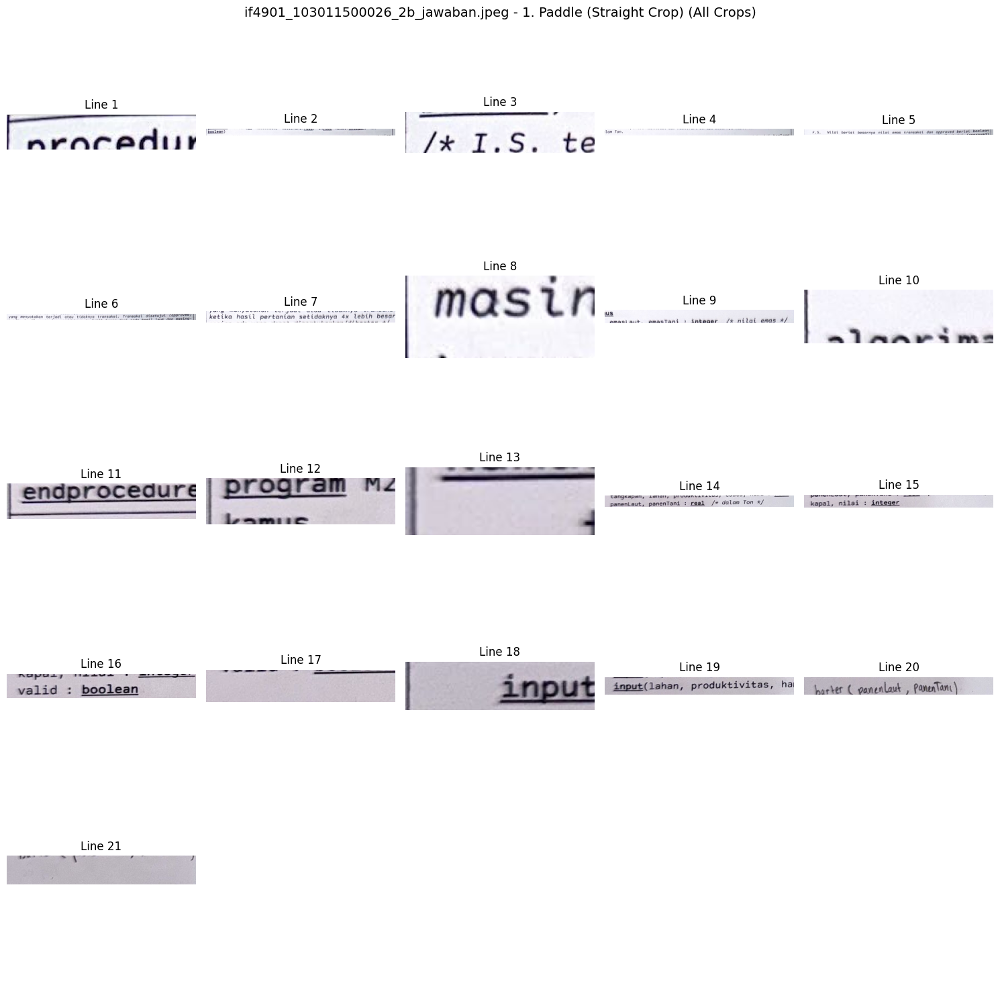

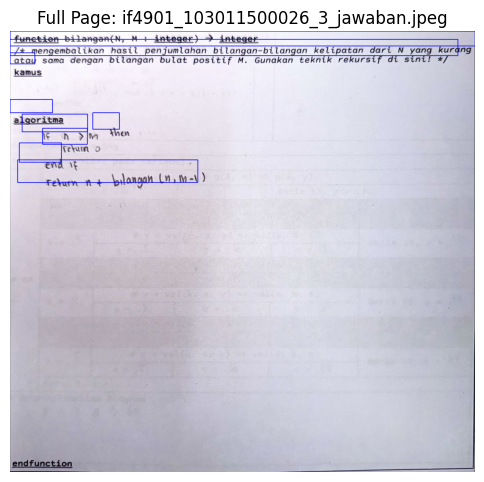

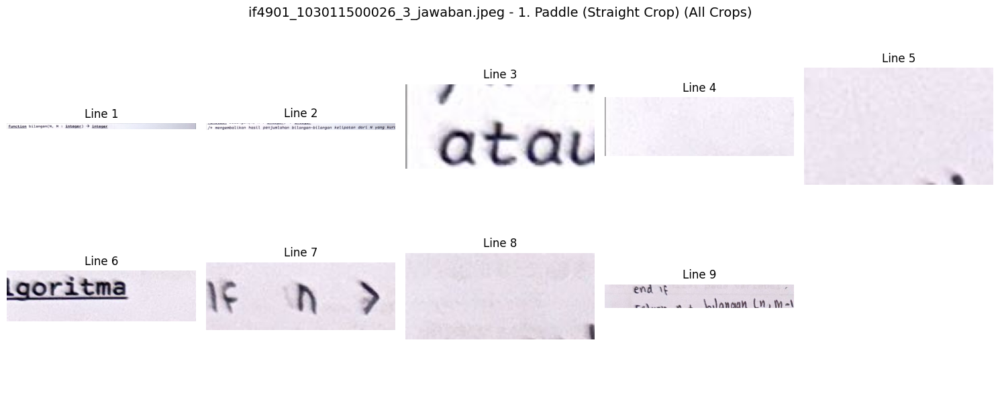

In [3]:
from paddleocr import PaddleOCR

# --- TEKNIK 1: PaddleOCR dengan Straight Crop ---
# Menginisialisasi PaddleOCR berbahasa Inggris (lang="en") tanpa MKLDNN (CPU standar)
ocr_straight = PaddleOCR(lang="en", enable_mkldnn=False)

for img_path in image_files:
    img_name = Path(img_path).name
    img = cv2.imread(img_path)
    
    # Deteksi teks menggunakan PaddleOCR
    det_results = ocr_straight.ocr(img_path)
    boxes = []
    
    # Mengekstrak koordinat bounding box hasil deteksi
    if det_results and len(det_results) > 0:
        first_res = det_results[0]
        if hasattr(first_res, "get"):
            boxes = first_res.get("dt_polys", first_res.get("rec_boxes", first_res.get("boxes", [])))
        elif isinstance(first_res, list):
            for line in first_res:
                if isinstance(line, list) and len(line) >= 2 and isinstance(line[0], list):
                    boxes.append(line[0])
                    
    # Fungsi pembantu untuk mengurutkan kotak berdasarkan posisi Y (dari atas ke bawah)
    def get_top_y(box): return min(p[1] for p in box)
    if boxes:
        boxes = sorted(boxes, key=get_top_y)
    
    # Menampilkan gambar asli dengan bounding box miring (warna hijau/biru)
    plot_full_img_with_boxes(img, boxes, img_name, is_straight=True, margin=3)
    
    # Melakukan Straight Crop (crop persegi sejajar sumbu X-Y) untuk tiap bounding box
    crops = []
    margin = 3
    for box in boxes:
        box_np = np.array(box, dtype=np.int32)
        x, y, w, h = cv2.boundingRect(box_np)
        y_start = max(0, y - margin)
        y_end = min(img.shape[0], y + h + margin)
        x_start = max(0, x - margin)
        x_end = min(img.shape[1], x + w + margin)
        crop_img = img[y_start:y_end, x_start:x_end]
        if crop_img.size > 0:
            crops.append(crop_img)
            
    # Menampilkan grid hasil crop
    plot_crops(img_name, "1. Paddle (Straight Crop)", crops)


### 2. PaddleOCR (Perspective Crop)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24072\2745439188.py:3: DeprecationWarning: The parameter `det_db_unclip_ratio` has been deprecated and will be removed in the future. Please use `text_det_unclip_ratio` instead.
  ocr_perspective = PaddleOCR(lang="en", enable_mkldnn=False, det_db_unclip_ratio=2.0)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ASUS\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ASUS\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ASUS\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model fi

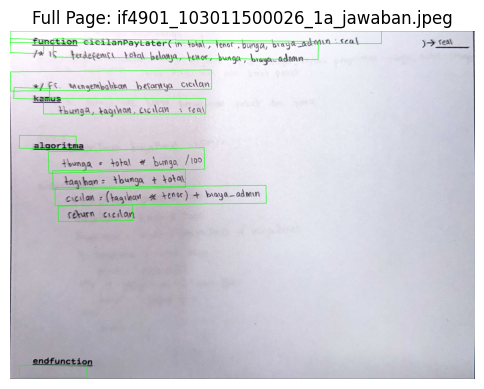

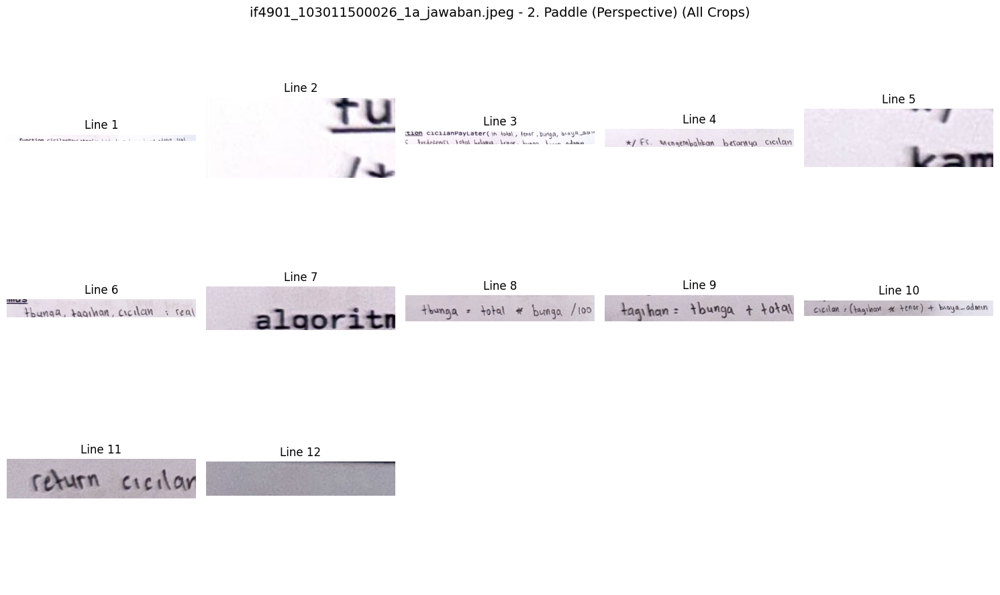

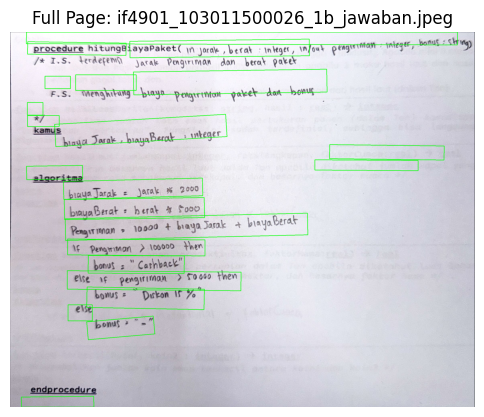

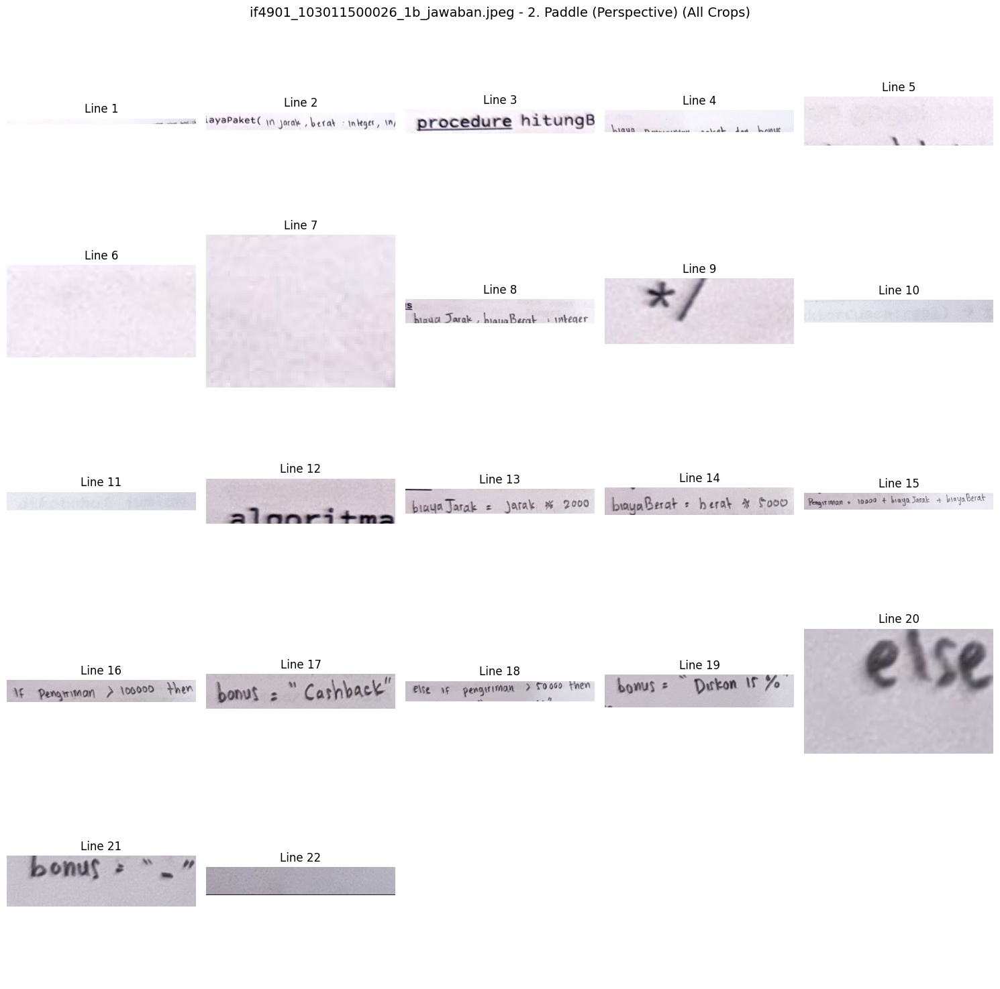

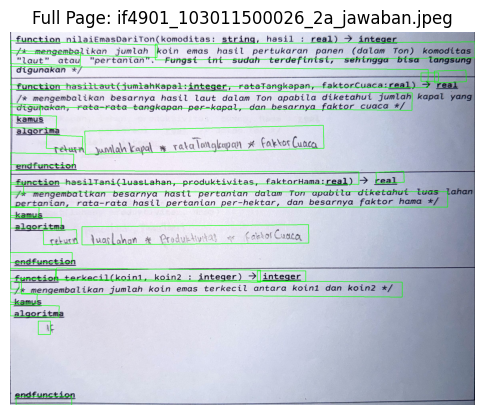

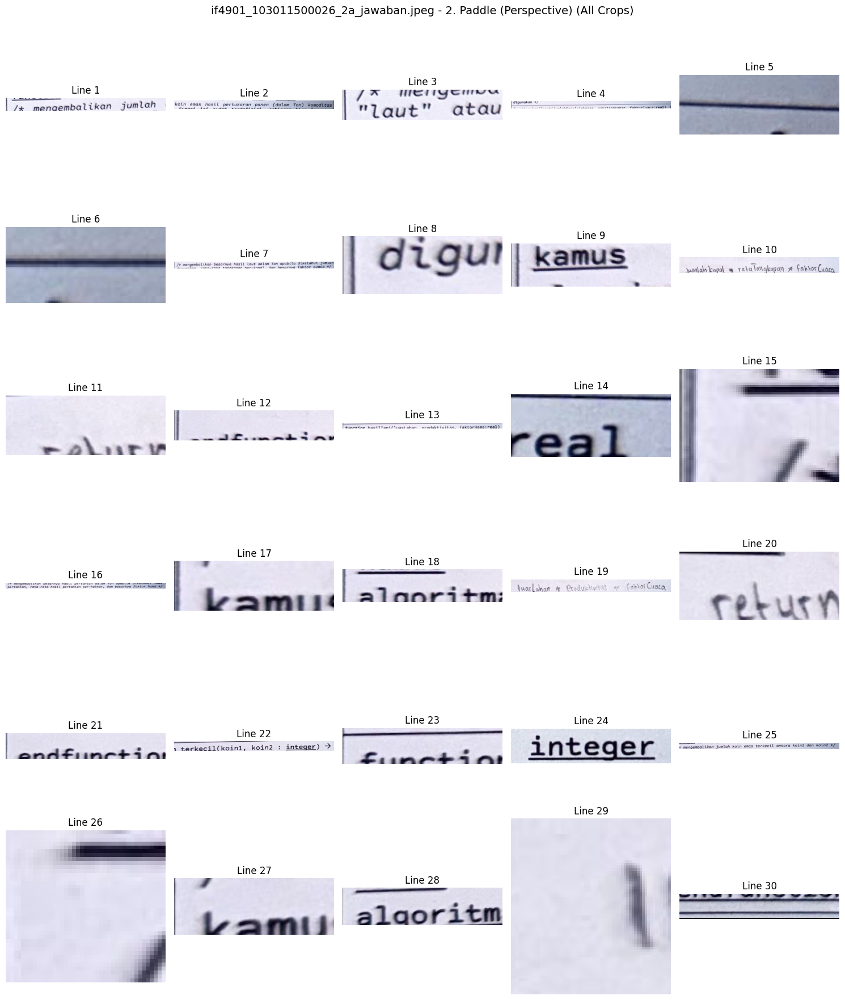

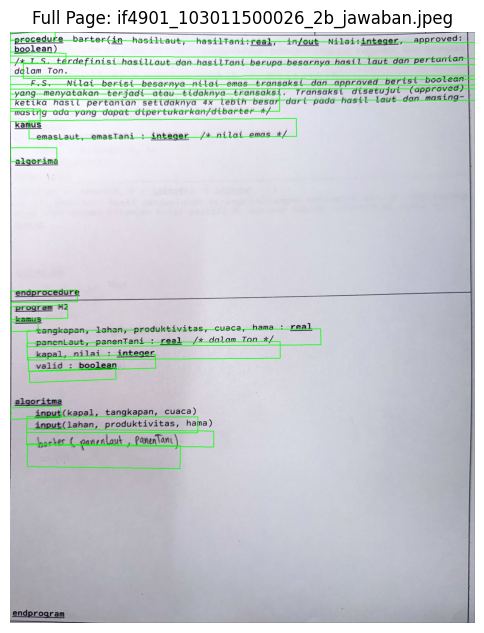

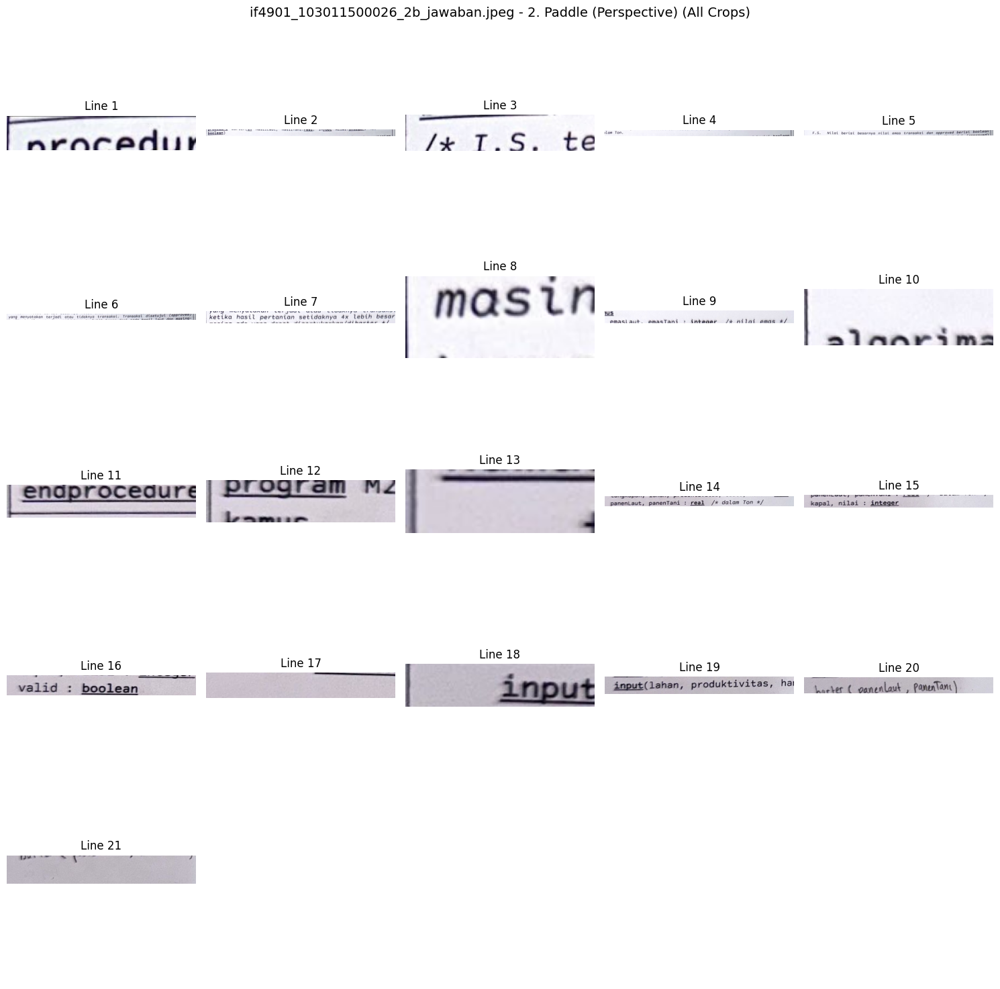

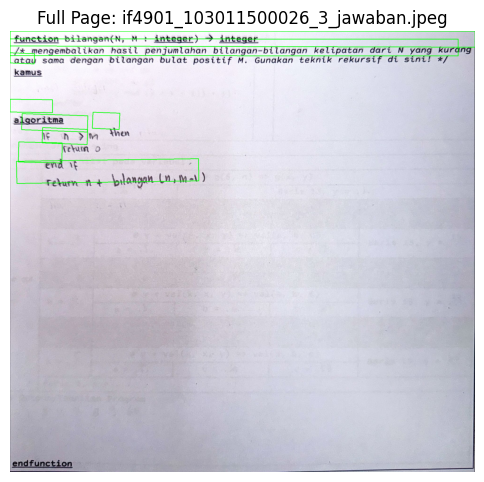

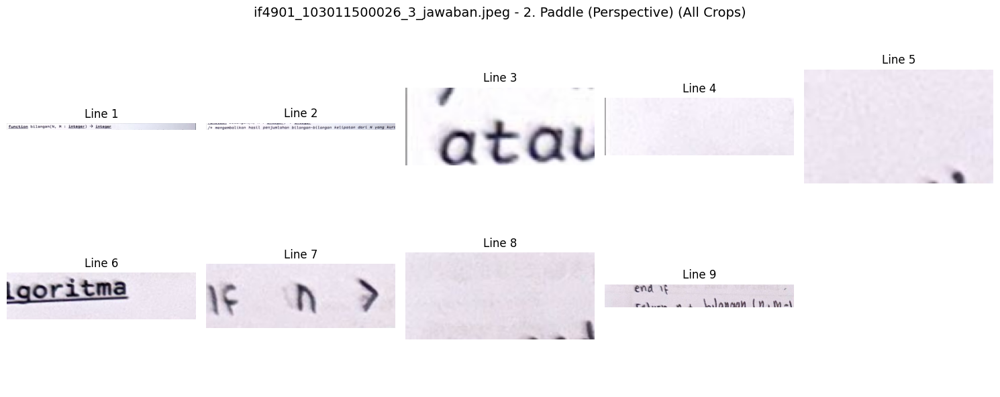

In [4]:
# --- TEKNIK 2: PaddleOCR dengan Perspective Crop ---
# Menginisialisasi PaddleOCR dengan parameter unclip_ratio lebih besar untuk menangkap area lebih luas
ocr_perspective = PaddleOCR(lang="en", enable_mkldnn=False, det_db_unclip_ratio=2.0)

for img_path in image_files:
    img_name = Path(img_path).name
    img = cv2.imread(img_path)
    
    # Deteksi teks menggunakan PaddleOCR
    det_results = ocr_perspective.ocr(img_path)
    boxes = []
    
    # Mengekstrak koordinat bounding box hasil deteksi
    if det_results and len(det_results) > 0:
        first_res = det_results[0]
        if hasattr(first_res, "get"):
            boxes = first_res.get("dt_polys", first_res.get("rec_boxes", first_res.get("boxes", [])))
        elif isinstance(first_res, list):
            for line in first_res:
                if isinstance(line, list) and len(line) >= 2 and isinstance(line[0], list):
                    boxes.append(line[0])
                    
    # Mengurutkan kotak berdasarkan posisi Y (dari atas ke bawah)
    def get_top_y(box): return min(p[1] for p in box)
    if boxes:
        boxes = sorted(boxes, key=get_top_y)
    
    # Menampilkan gambar asli dengan bounding box miring
    plot_full_img_with_boxes(img, boxes, img_name)
    
    # Melakukan Crop menggunakan Perspective Transform (meluruskan teks miring)
    crops = []
    for box in boxes:
        box_np = np.array(box, dtype=np.float32)
        warped = get_perspective_crop(img, box_np)
        if warped.size > 0:
            crops.append(warped)
            
    # Menampilkan grid hasil crop
    plot_crops(img_name, "2. Paddle (Perspective)", crops)


### 3. CRAFT Text Detector

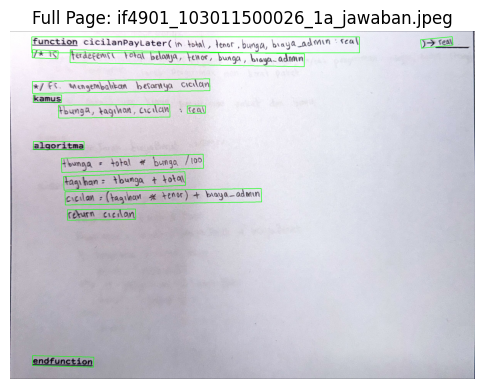

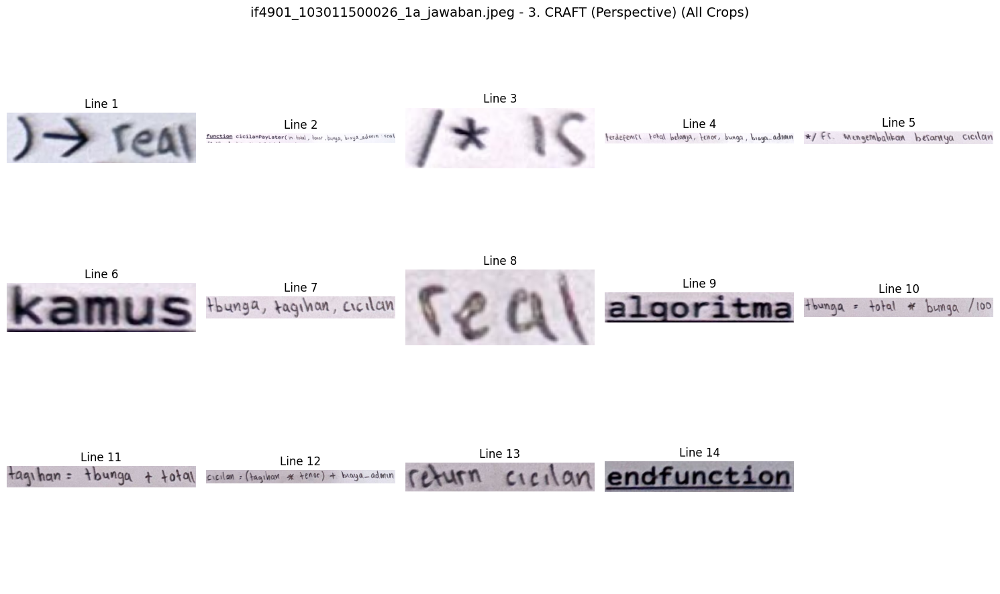

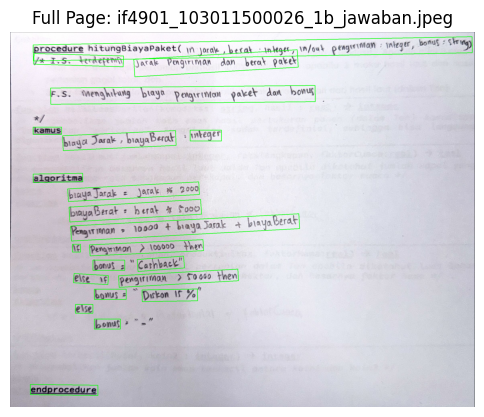

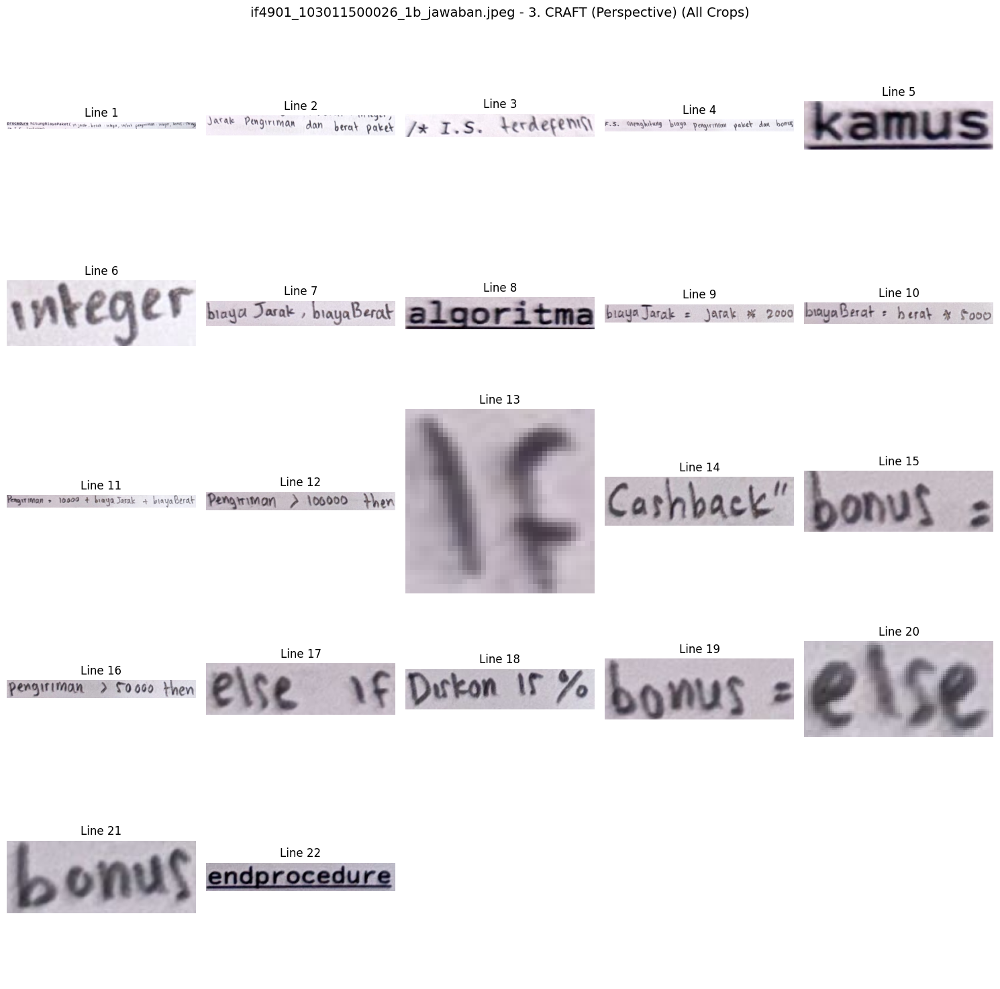

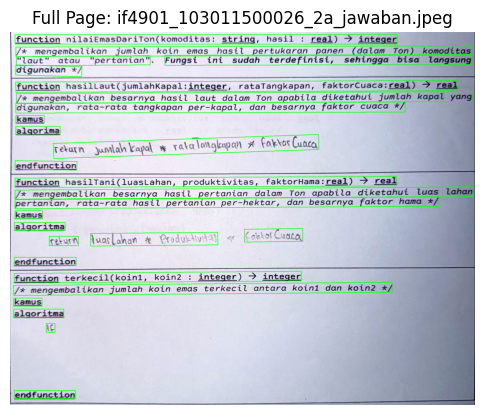

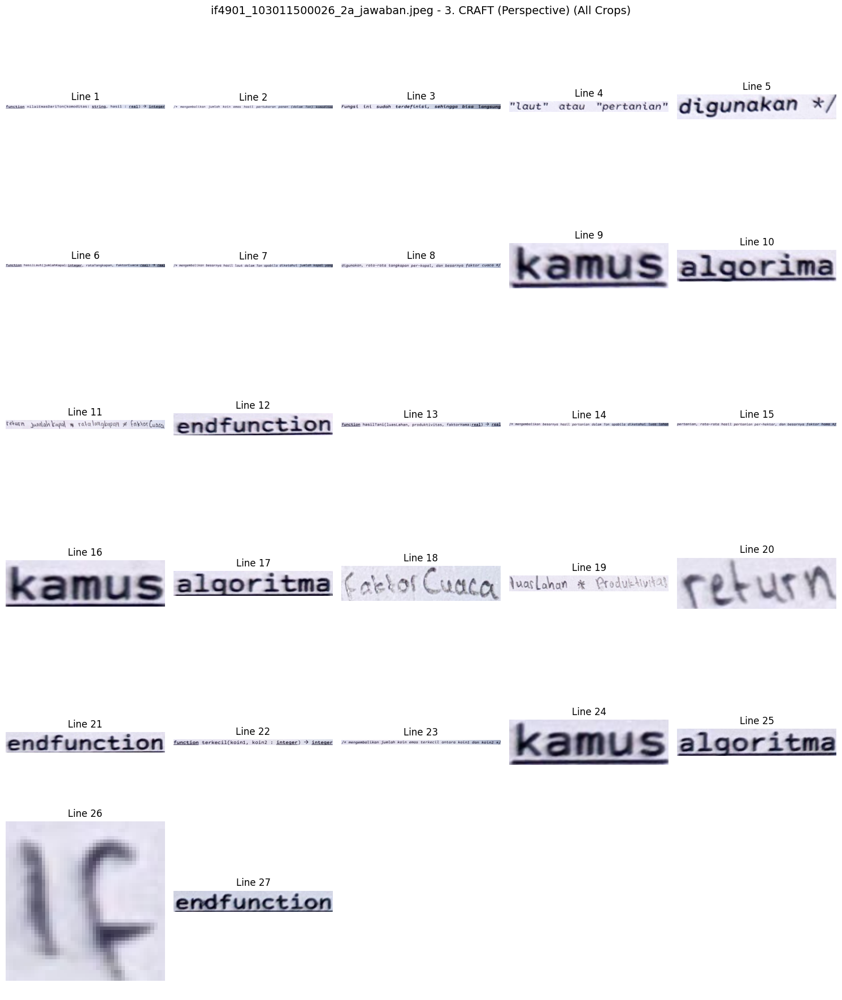

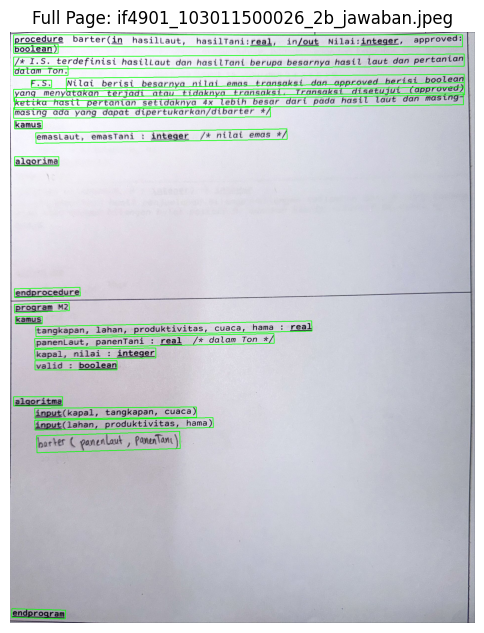

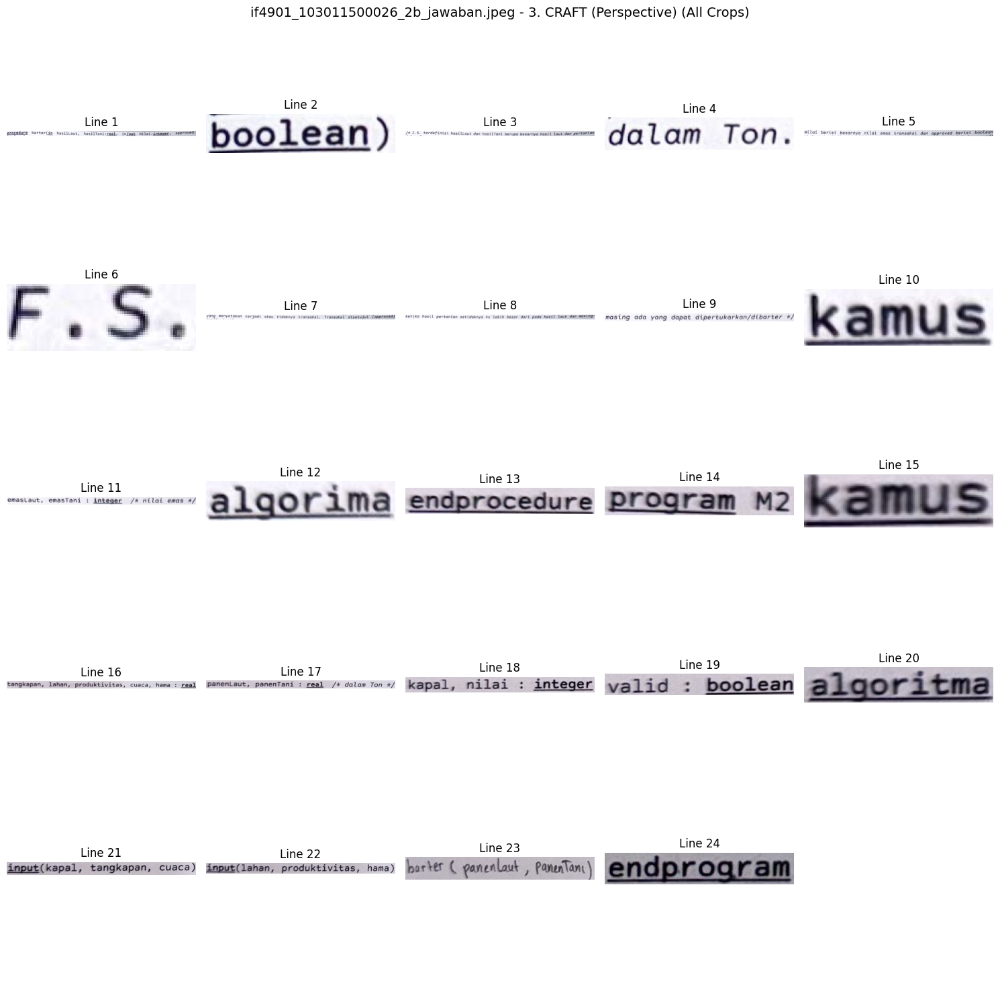

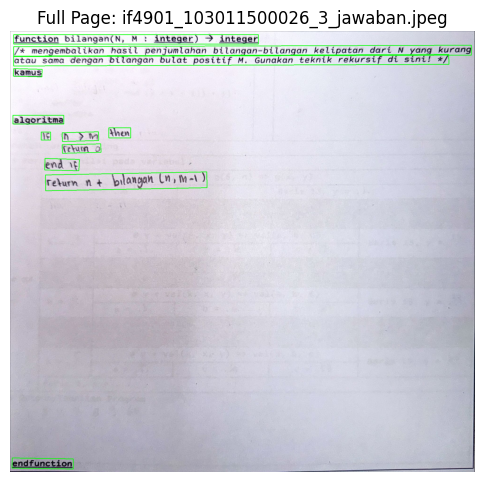

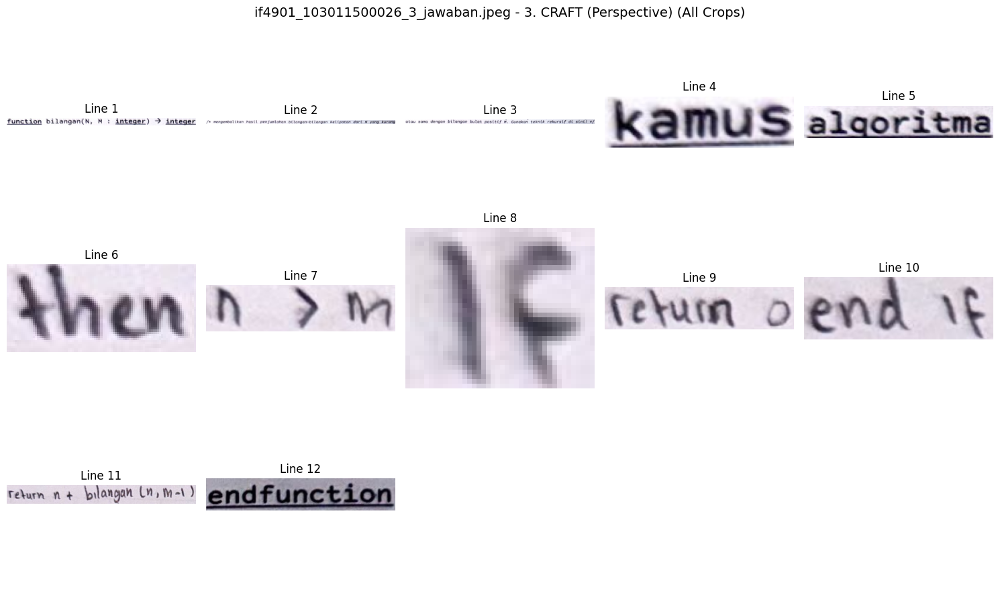

In [5]:
import torchvision.models.vgg as vgg
# Konfigurasi URL model VGG untuk CRAFT
vgg.model_urls = {'vgg16_bn': 'https://download.pytorch.org/models/vgg16_bn-6c64b313.pth'}

# --- PATCH numpy.array untuk CRAFT ---
# CRAFT memerlukan patch numpy agar bisa menerima list dengan ukuran tidak homogen (ragged array)
import numpy as np
if not hasattr(np, '_true_original_array'):
    np._true_original_array = np.array

def patched_array(obj, *args, **kwargs):
    try:
        return np._true_original_array(obj, *args, **kwargs)
    except ValueError as e:
        if "inhomogeneous" in str(e) or "sequence" in str(e):
            kwargs['dtype'] = object
            return np._true_original_array(obj, *args, **kwargs)
        raise
np.array = patched_array

from craft_text_detector import Craft
import warnings
warnings.filterwarnings("ignore")

# --- TEKNIK 3: CRAFT Text Detector ---
# Menginisialisasi CRAFT (menggunakan CPU karena cuda=False)
craft = Craft(output_dir="craft_outputs", crop_type="poly", cuda=False)

for img_path in image_files:
    img_name = Path(img_path).name
    img = cv2.imread(img_path)
    
    # Deteksi teks menggunakan CRAFT
    prediction_result = craft.detect_text(img_path)
    boxes = prediction_result["boxes"]
    
    # Mengurutkan kotak berdasarkan posisi Y (dari atas ke bawah)
    def get_top_y(box): return min(p[1] for p in box)
    if len(boxes) > 0:
        boxes = sorted(boxes, key=get_top_y)
    
    # Menampilkan gambar asli dengan bounding box miring hasil CRAFT
    plot_full_img_with_boxes(img, boxes, img_name)
    
    # Melakukan Perspective Crop pada kotak yang dihasilkan CRAFT
    crops = []
    for box in boxes:
        # Konversi koordinat box secara aman menggunakan numpy patch
        box_np = np._true_original_array(list(box), dtype=np.int32)
        rect = cv2.minAreaRect(box_np)
        box_4pts = cv2.boxPoints(rect)
        box_4pts = np.int32(box_4pts)
        
        warped = get_perspective_crop(img, box_4pts.astype(np.float32))
        if warped.size > 0:
            crops.append(warped)
            
    # Menampilkan grid hasil crop
    plot_crops(img_name, "3. CRAFT (Perspective)", crops)

# Kembalikan numpy.array ke bentuk aslinya setelah proses CRAFT selesai
np.array = np._true_original_array


### 4. YOLOv8 OBB (Zero-shot)

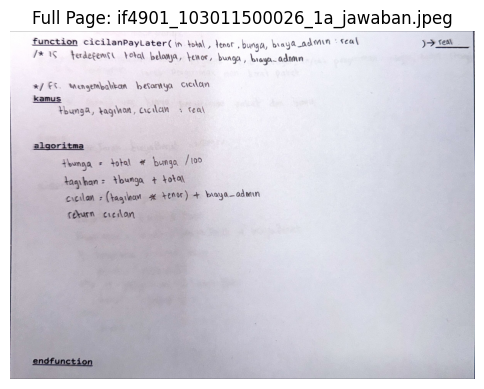

[4. YOLOv8 OBB (Zero-shot DOTA)] Tidak ada deteksi untuk if4901_103011500026_1a_jawaban.jpeg


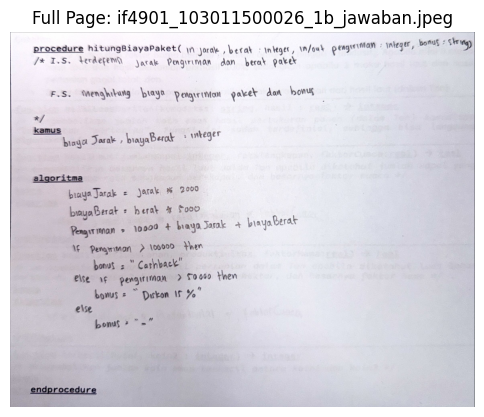

[4. YOLOv8 OBB (Zero-shot DOTA)] Tidak ada deteksi untuk if4901_103011500026_1b_jawaban.jpeg


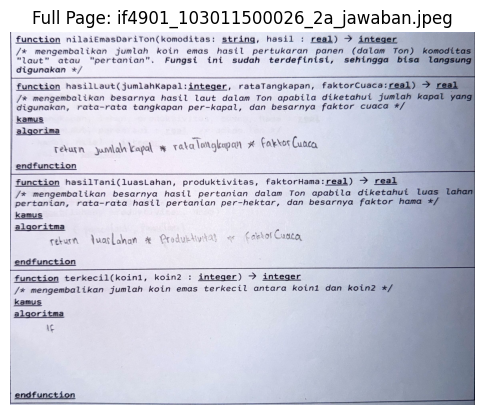

[4. YOLOv8 OBB (Zero-shot DOTA)] Tidak ada deteksi untuk if4901_103011500026_2a_jawaban.jpeg


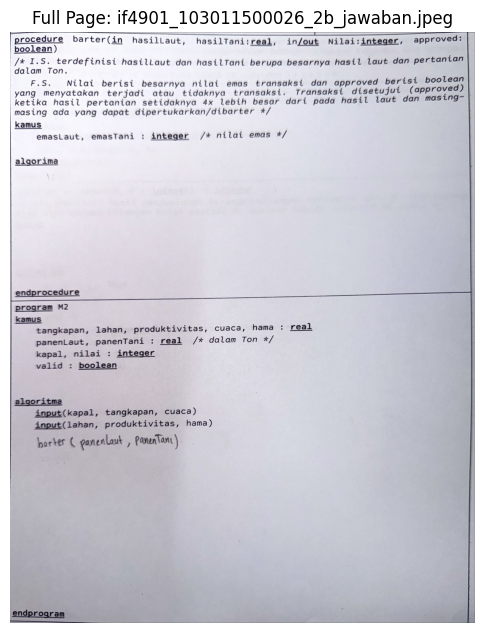

[4. YOLOv8 OBB (Zero-shot DOTA)] Tidak ada deteksi untuk if4901_103011500026_2b_jawaban.jpeg


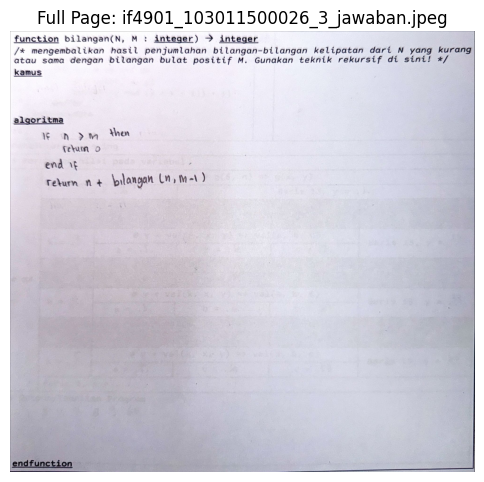

[4. YOLOv8 OBB (Zero-shot DOTA)] Tidak ada deteksi untuk if4901_103011500026_3_jawaban.jpeg


In [6]:
from ultralytics import YOLO

# --- TEKNIK 4: YOLOv8 OBB (Oriented Bounding Box) ---
# Memuat pretrained model YOLOv8 OBB (DOTA Dataset)
model_yolo = YOLO('yolov8n-obb.pt') 

for img_path in image_files:
    img_name = Path(img_path).name
    img = cv2.imread(img_path)
    
    # Prediksi menggunakan YOLOv8 OBB
    results = model_yolo(img_path, verbose=False)
    
    crops = []
    yolo_boxes = []
    for r in results:
        obb = r.obb
        # Mengambil koordinat miring (4 titik) dari objek terdeteksi
        if obb is not None and len(obb) > 0:
            for box in obb.xyxyxyxy.cpu().numpy():
                yolo_boxes.append(box)
                box_np = np.array(box, dtype=np.float32)
                # Melakukan Perspective Crop untuk meluruskan teks miring
                warped = get_perspective_crop(img, box_np)
                if warped.size > 0:
                    crops.append(warped)
                    
    # Menampilkan gambar asli dengan bounding box miring YOLOv8
    plot_full_img_with_boxes(img, yolo_boxes, img_name)
    # Menampilkan grid hasil crop
    plot_crops(img_name, "4. YOLOv8 OBB (Zero-shot DOTA)", crops)
